**TEST TRAIN SPLIT & NAIVE MODEL**

# TEST TRAIN SPLIT

- *IN A TIME SERIES DATA UNLIKE A NORMAL DATA WE CANNOT RANDOMLY CHOOSE DATA FOR TRAIN AND TEST*
- *WE USE MAJORITY OF THE DATA TO TRAIN*

In [12]:
import pandas as pd

In [13]:
df = pd.read_csv('daily-min-temperatures.csv', header=0, parse_dates=[0])
df.head()

,Date,Temp
0,1981-01-01,20.7
1,1981-01-02,17.9
2,1981-01-03,18.8
3,1981-01-04,14.6
4,1981-01-05,15.8


In [7]:
df.shape

(3650, 2)

In [8]:
df.shape[0]

3650

In [14]:
train_size = int(df.shape[0]*0.8)
train_size 

2920

In [18]:
train = df[0:train_size]
test = df[train_size:]

In [19]:
train.shape

(2920, 2)

In [20]:
test.shape

(730, 2)

# NAIVE MODEL

In [21]:
df.head()

,Date,Temp
0,1981-01-01,20.7
1,1981-01-02,17.9
2,1981-01-03,18.8
3,1981-01-04,14.6
4,1981-01-05,15.8


In [23]:
df['t'] = df['Temp'].shift(1)
df.head()

,Date,Temp,t
0,1981-01-01,20.7,NaN
1,1981-01-02,17.9,20.7
2,1981-01-03,18.8,17.9
3,1981-01-04,14.6,18.8
4,1981-01-05,15.8,14.6


In [28]:
# test value last 5 values, remaining data we use to train
train, test = df[1:df.shape[0]-5], df[df.shape[0]-5:]
train.head()

,Date,Temp,t
1,1981-01-02,17.9,20.7
2,1981-01-03,18.8,17.9
3,1981-01-04,14.6,18.8
4,1981-01-05,15.8,14.6
5,1981-01-06,15.8,15.8


In [29]:
train_X, train_y = train['t'],train['Temp']
test_X, test_y = test['t'],test['Temp']

In [30]:
predictions = test_X.copy()

In [31]:
print(predictions)
print(test_y)

3645    14.6
3646    14.0
3647    13.6
3648    13.5
3649    15.7
Name: t, dtype: float64
3645    14.0
3646    13.6
3647    13.5
3648    15.7
3649    13.0
Name: Temp, dtype: float64


In [36]:
# to calculate error because if other models having error greater than this we say that our TS is a random_walk.
from sklearn.metrics import mean_squared_error
mse = mean_squared_error(test_y,predictions)
mse

2.5319999999999987

In [34]:
# plotting predicted and actual values
from matplotlib import pyplot

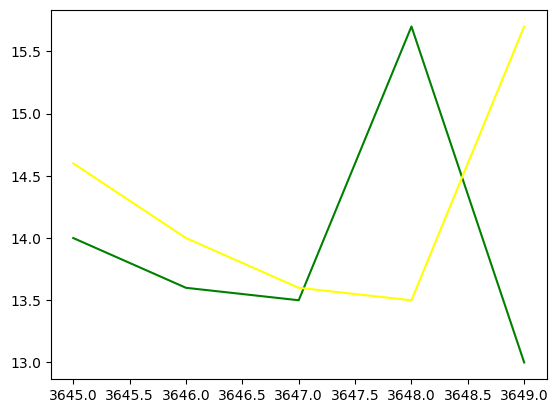

In [35]:
pyplot.plot(test_y, color='green')
pyplot.plot(predictions, color='yellow')